In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import legendre, legendre_p
import pysindy as ps

# import modules from parent dir
# from <https://stackoverflow.com/questions/714063/importing-modules-from-parent-folder>
import os
# below no worki, maybe because of ipynb?
# import sys
# import inspect
# currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
# print(currentdir)
# parentdir = os.path.dirname(currentdir)
# print(parentdir)
# sys.path.insert(0, parentdir)

currentdir = os.getcwd()
if currentdir.split("/")[-1] != 'yukawa-sindy':
    parentdir = os.path.dirname(currentdir)
    os.chdir(parentdir)

import Yukawa_SINDy as ys
import cross_validation as cv
import pickle as pkl
import anisotropic_potential as ap

# import Yukawa scaling constant
with open('scaling_const.float', 'rb') as f:
    SCALING_CONST = pkl.load(f)

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'figure.figsize': (8,6)})

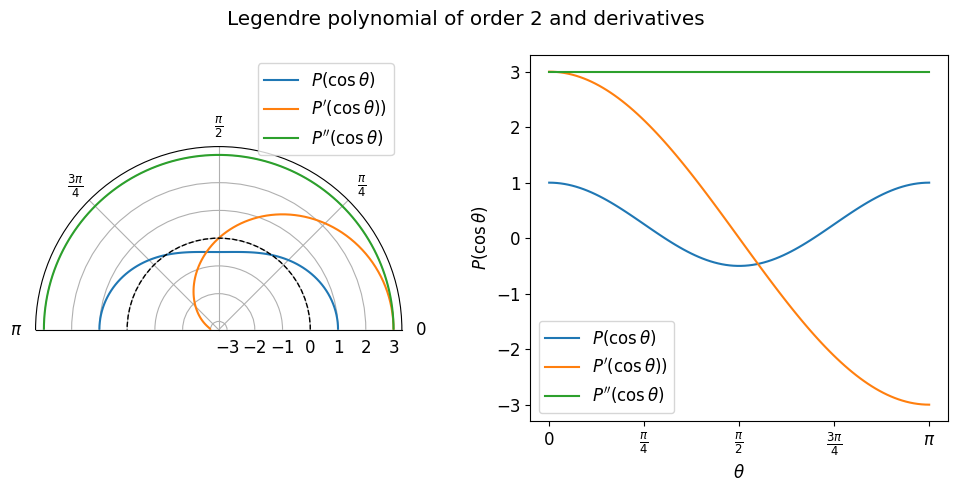

In [2]:
order = 2
theta = np.r_[0:np.pi:100j]
x = np.cos(theta)
y = legendre_p(order, x, diff_n = 2).T

fig, axd = plt.subplot_mosaic("AB", per_subplot_kw={"A": {'projection': 'polar'}},figsize=(10,5))
for key in axd.keys():
    axd[key].plot(theta, y, label = ["$P(\\cos\\theta)$", "$P'(\\cos\\theta))$", "$P''(\\cos\\theta)$"])
    axd[key].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
    axd[key].set_xticklabels(['0', '$\\frac{\\pi}{4}$', '$\\frac{\\pi}{2}$', '$\\frac{3\\pi}{4}$', '$\\pi$'])
    axd[key].legend()

axd['A'].set_thetamax(180)
axd['A'].axhline(c='black', lw=1, ls='--')

axd['B'].set_xlabel('$\\theta$')
axd['B'].set_ylabel('$P(\cos\\theta)$')
# axd['B'].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
# axd['B'].set_xticklabels(['0', '$\\frac{\\pi}{4}$', '$\\frac{\\pi}{2}$', '$\\frac{3\\pi}{4}$', '$\\pi$'])

fig.suptitle(f"Legendre polynomial of order {order} and derivatives")
fig. tight_layout()

In [3]:
test = legendre_p(order, x, diff_n = 2)
test.shape

(3, 100)

In [74]:
from importlib import reload
reload(ap)

<module 'anisotropic_potential' from '/Users/zbh0005/Library/CloudStorage/OneDrive-AuburnUniversity/Documents/Code/yukawa-sindy/anisotropic_potential.py'>

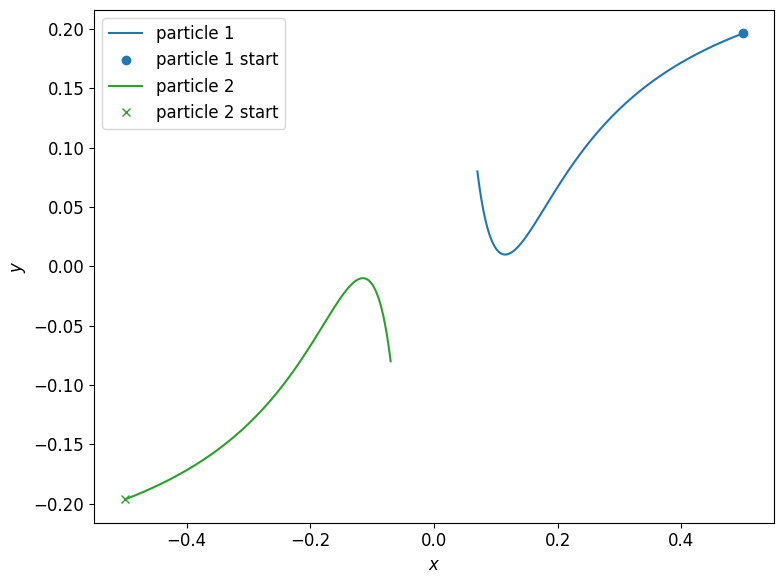

In [75]:
# rng=np.random.default_rng(seed=34123)
rng=None
sim = ap.Anisotropic_simulation(rng=rng)
duration = 0.08
dt = duration / 1e3
r0 = 1
p0 = -10
theta0 = np.pi/8
l0 = -2
x0 = np.array([r0, p0, theta0, l0])
sim.simulate(duration, dt, x0=x0)
sim.plot()

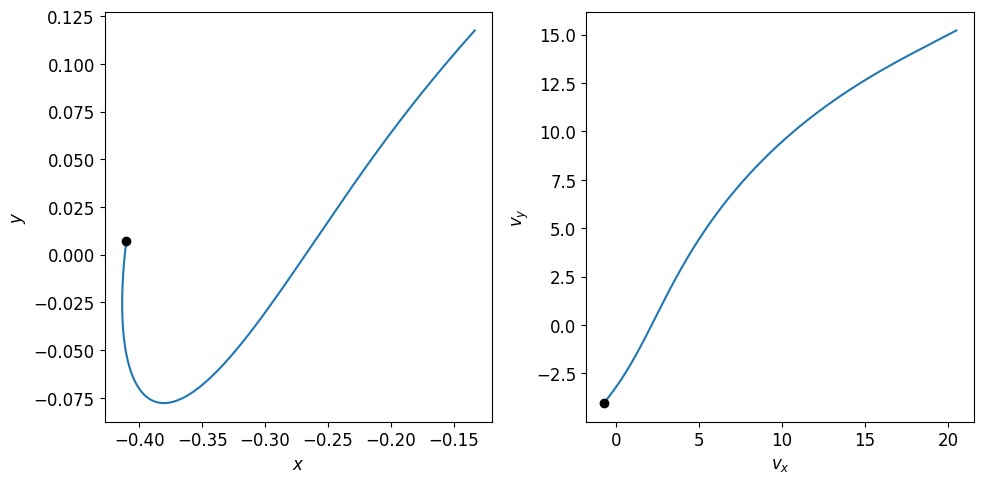

In [11]:
x       = sim.x_cart[:, 0]
x0     = sim.x0_cart[0]
vx     = sim.x_cart[:, 1]
vx0    = sim.x0_cart[1]
y       = sim.x_cart[:, 2]
y0     = sim.x0_cart[2]
vy     = sim.x_cart[:, 3]
vy0    = sim.x0_cart[3]

fig, axs = plt.subplots(1,2, figsize=(10,5))
axs[0].plot(x,y)
axs[0].plot(x0,y0,'ko')
axs[0].set_xlabel("$x$")
axs[0].set_ylabel("$y$")

axs[1].plot(vx, vy)
axs[1].plot(vx0,vy0,'ko')
axs[1].set_xlabel("$v_x$")
axs[1].set_ylabel("$v_y$")

fig.tight_layout()

In [112]:
sim.x0_cart

array([-0.41026297, -0.73377137,  0.00707531, -4.03267747])

In [113]:
sim.x0

array([0.41032397, 0.66412593, 3.12434858, 1.65964988])

To make a bit more sense of this, I might want to convert back to absolute coordinates instead of center-of-mass coordinates. It is a bit difficult to visualize what is happening when plotting the $x$- and $y$-components of the interparticle spacing.